# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/tweet_sentiment_train.csv.zip')

In [4]:
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [6]:
df = df[(~df['text'].isna()) & (~df['selected_text'].isna())]

### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [7]:
df['sentiment'].value_counts(normalize=True)

,proportion
sentiment,
neutral,0.404549
positive,0.312300
negative,0.283151


In [8]:
df['len_text'] = df['text'].str.len()


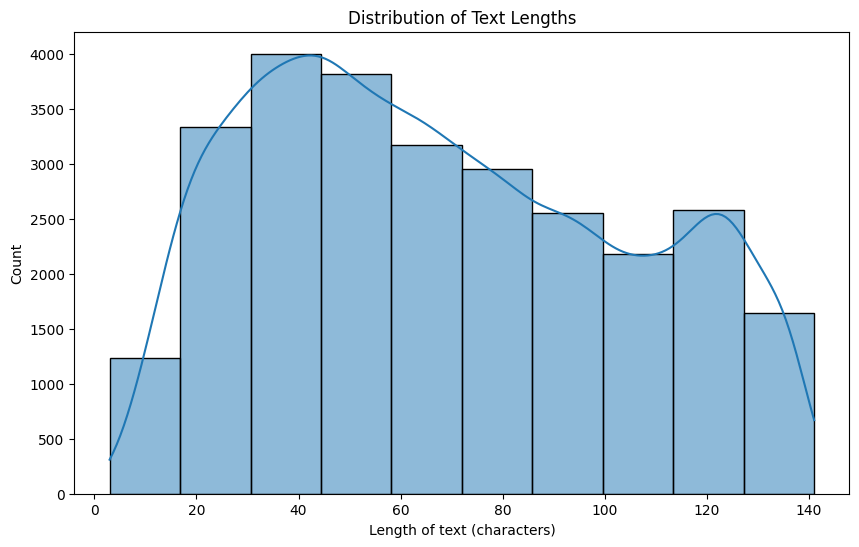

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df['len_text'], bins=10, kde=True)
plt.title('Distribution of Text Lengths')
plt.xlabel('Length of text (characters)')
plt.ylabel('Count')
plt.show()

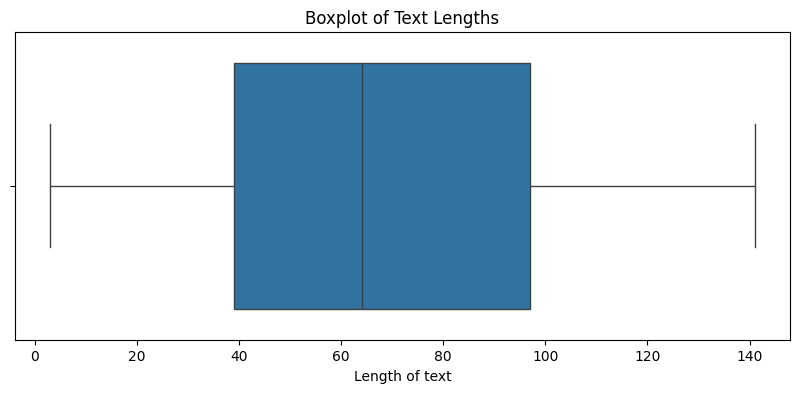

In [10]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['len_text'])
plt.title('Boxplot of Text Lengths')
plt.xlabel('Length of text')
plt.show()

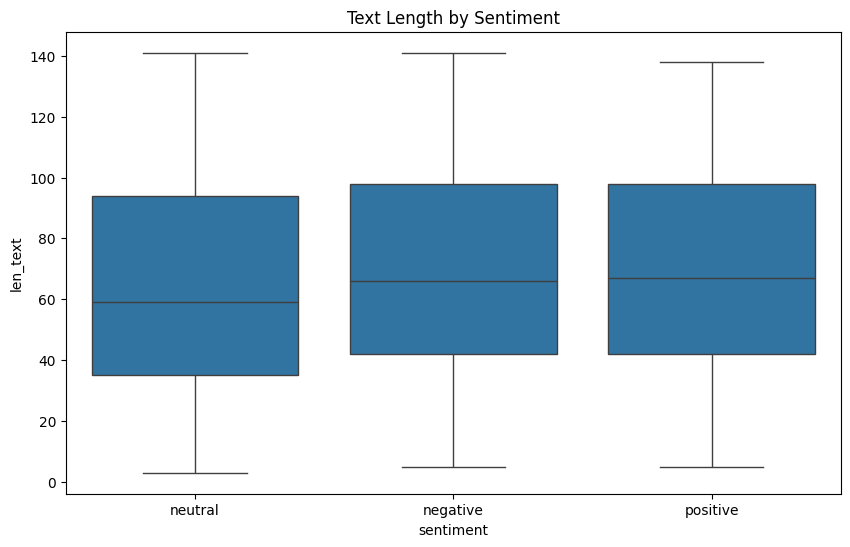

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='sentiment', y='len_text')
plt.title('Text Length by Sentiment')
plt.show()

In [12]:
df.groupby('sentiment')['len_text'].median()

,len_text
sentiment,
negative,66.0
neutral,59.0
positive,67.0


**Висновки**

- більше всього постів з neutral sentiment (40,5%) і трохи меньше positive (31,2%) і negative (28,3%)

- найбільша кількість постів має довжину 30–50 символів

- основна маса постів мають від 40 до 100 символів

- розподіл довжин є помірно правосторонньо скошеним, коротких постів більше, а дуже довгі зустрічаються рідше

- якщо дивитись по сентименту, нейтральні пости мають трохи меньше довжину, медіана 59 символів, у негативних і позитивних розподіл і медіана схожі - 66 та 67 символів

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [13]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [14]:
english_stopwords = stopwords.words('english')
stemmer = SnowballStemmer("english")

In [15]:
def preprocess(text):
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+', '', text)

    # keep only letters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # tokenize
    tokens = word_tokenize(text)

    # remove stopwords + stemming
    tokens = [
        stemmer.stem(word)
        for word in tokens
        if word not in english_stopwords and len(word) > 2
    ]

    return tokens

In [16]:
vectorizer = CountVectorizer(
    tokenizer=preprocess,
    lowercase=False,
    max_features=3000
)

**Висновки**

- було виконано очищення тексту, видалено stopwords, проведено токенізацію та стеммінг

- для векторизації використано CountVectorizer з обмеженням словника до 3000 найбільш частотних слів

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [17]:
from sklearn.model_selection import train_test_split

In [18]:
df_model = df.dropna(subset=['text', 'sentiment']).reset_index(drop=True)

In [19]:
train_idx, test_idx = train_test_split(
    df_model.index,
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment']
)

In [20]:
inputs_bow = vectorizer.fit_transform(df_model['text'])

X_train_bow = inputs_bow[train_idx]
X_test_bow = inputs_bow[test_idx]

y_train = df_model.loc[train_idx, 'sentiment']
y_test = df_model.loc[test_idx, 'sentiment']

label_map = {'negative': 0, 'neutral': 1, 'positive': 2}

y_train_xgb = y_train.map(label_map)
y_test_xgb = y_test.map(label_map)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_bow, y_train)

y_pred_lr = model_lr.predict(X_test_bow)

print("------Logistic Regression model------")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

------Logistic Regression model------
Accuracy: 0.6850436681222707
              precision    recall  f1-score   support

    negative       0.70      0.62      0.66      1556
     neutral       0.63      0.71      0.67      2223
    positive       0.76      0.71      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.70      0.68      0.69      5496
weighted avg       0.69      0.69      0.69      5496



In [22]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()

model_nb.fit(X_train_bow, y_train)

y_pred_nb = model_nb.predict(X_test_bow)

print("------Naive Bayes model------")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

------Naive Bayes model------
Accuracy: 0.6539301310043668
              precision    recall  f1-score   support

    negative       0.67      0.62      0.65      1556
     neutral       0.60      0.67      0.63      2223
    positive       0.72      0.67      0.69      1717

    accuracy                           0.65      5496
   macro avg       0.66      0.65      0.66      5496
weighted avg       0.66      0.65      0.65      5496



In [23]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC()

model_svm.fit(X_train_bow, y_train)

y_pred_svm = model_svm.predict(X_test_bow)

print("------SVM model------")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

------SVM model------
Accuracy: 0.6735807860262009
              precision    recall  f1-score   support

    negative       0.68      0.62      0.65      1556
     neutral       0.63      0.68      0.65      2223
    positive       0.73      0.71      0.72      1717

    accuracy                           0.67      5496
   macro avg       0.68      0.67      0.68      5496
weighted avg       0.68      0.67      0.67      5496



In [24]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(
    max_depth=30,
    min_samples_split=10,
    random_state=42
)

model_tree.fit(X_train_bow, y_train)

y_pred_tree = model_tree.predict(X_test_bow)

print("------Decision Tree------")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

------Decision Tree------
Accuracy: 0.6408296943231441
              precision    recall  f1-score   support

    negative       0.76      0.38      0.51      1556
     neutral       0.56      0.85      0.67      2223
    positive       0.78      0.61      0.68      1717

    accuracy                           0.64      5496
   macro avg       0.70      0.61      0.62      5496
weighted avg       0.68      0.64      0.63      5496



In [25]:
X_train_dense = X_train_bow.toarray()
X_test_dense = X_test_bow.toarray()

In [26]:
from sklearn.ensemble import AdaBoostClassifier

base_tree = DecisionTreeClassifier(max_depth=3)

model_boost = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

model_boost.fit(X_train_dense, y_train)

y_pred_boost = model_boost.predict(X_test_dense)

print("------AdaBoost------")
print("Accuracy:", accuracy_score(y_test, y_pred_boost))
print(classification_report(y_test, y_pred_boost))

------AdaBoost------
Accuracy: 0.6060771470160117
              precision    recall  f1-score   support

    negative       0.82      0.30      0.44      1556
     neutral       0.52      0.89      0.65      2223
    positive       0.80      0.52      0.63      1717

    accuracy                           0.61      5496
   macro avg       0.71      0.57      0.57      5496
weighted avg       0.69      0.61      0.59      5496



In [41]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    n_estimators=300,
    learning_rate = 0.2,
    random_state=42,
    eval_metric='mlogloss'
)

model_xgb.fit(X_train_bow, y_train_xgb)

y_pred_xgb = model_xgb.predict(X_test_bow)

print("------XGBoost------")
print("Accuracy:", accuracy_score(y_test_xgb, y_pred_xgb))
print(classification_report(y_test_xgb, y_pred_xgb))


------XGBoost------
Accuracy: 0.7079694323144105
              precision    recall  f1-score   support

           0       0.76      0.59      0.67      1556
           1       0.64      0.77      0.70      2223
           2       0.78      0.73      0.75      1717

    accuracy                           0.71      5496
   macro avg       0.73      0.70      0.71      5496
weighted avg       0.72      0.71      0.71      5496



**Висновки**

Для задачі класифікації тональності текстів було протестовано кілька алгоритмів машинного навчання на даних, векторизованих методом Bag of Words:

| Модель                  | Accuracy  |
| ----------------------- | --------- |
| XGBoost                 | 0.708     |  
| Logistic Regression     | 0.685     |
| Linear SVM              | 0.674     |
| Multinomial Naive Bayes | 0.654     |
| Decision Tree           | 0.640     |
| AdaBoost                | 0.606     |

Найкращий результат показала модель XGBoost, яка досягла точності 70.8%. На другому місці Logistic Regression 68.5%

Якість фінальної класифікації XGBoost я б оцінила як середню. Модель коректно класифікує  70% текстів, добре визначає positive клас,
результат є хорошим для базового підходу Bag of Words

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [43]:
feature_names = vectorizer.get_feature_names_out()

coef = model_lr.coef_
# DataFrame коефіцієнтів
coef_df = pd.DataFrame(coef.T, index=feature_names, columns=model_lr.classes_)

In [29]:
coef_df.sort_values(by='positive', ascending=False).head(10)

,negative,neutral,positive
awesom,-2.430375,-0.211467,2.641842
cute,-1.788091,-0.749100,2.537191
thank,-1.888702,-0.530339,2.419042
love,-2.134733,-0.240980,2.375712
glad,-2.347025,0.071460,2.275565
amaz,-1.637070,-0.613429,2.250499
enjoy,-1.667781,-0.430873,2.098653
nice,-1.540504,-0.538097,2.078601
congratul,-0.731475,-1.329541,2.061016
bless,-1.353547,-0.700640,2.054186


In [45]:
coef_df.sort_values(by='neutral', ascending=False).head(10)

,negative,neutral,positive
otherwis,-0.977861,1.309270,-0.331408
colorado,-0.760269,1.212765,-0.452496
starwarsday,-0.318780,1.198970,-0.880190
moro,-0.523172,1.183530,-0.660359
how,-0.676113,1.090299,-0.414185
jst,-0.257544,1.068978,-0.811434
england,-1.015189,1.052496,-0.037308
logic,-0.535300,1.039357,-0.504057
satisfi,-0.942273,1.038293,-0.096020
languag,-0.318433,1.036526,-0.718093


In [46]:
coef_df.sort_values(by='negative', ascending=False).head(10)

,negative,neutral,positive
sad,2.652243,-0.065951,-2.586292
suck,2.440170,-0.079118,-2.361052
sorri,2.428682,0.161954,-2.590637
bore,2.348385,-0.147772,-2.200613
hate,2.339219,-0.205201,-2.134019
fail,2.164854,-0.700982,-1.463872
worst,2.092449,-0.739735,-1.352714
stupid,2.065596,-0.845996,-1.219600
miss,2.041097,-0.181593,-1.859505
unfortun,2.016550,-0.094969,-1.921580


**Висновки**

Дослідила найбільш впливові слова для LR model:

- для класу positive: awesom, cute, thank, love, glad, amaz, enjoy,nice, congratul, bless

- для класу negative: sad, suck, sorri, bore, hate, fail, worst, stupid, miss, unfortun

- для класу neutral: otherwis, colorado, starwarsday, moro, how,
jst, england, logic, satisfi, languag

Результати виглядають цілком закономірними,
для positive та negative модель орієнтується на емоційно забарвлені слова, а для neutral модель використовує слова без вираженої емоції або тематичні токени

In [83]:
feature_names = vectorizer.get_feature_names_out()

feat_imp = pd.DataFrame({
    'token': feature_names,
    'importance': model_xgb.feature_importances_
})

feat_imp.sort_values('importance', ascending=False).head(20)

,token,importance
2613,thank,0.011684
1188,happi,0.011069
1197,hate,0.008282
81,amaz,0.006961
1564,love,0.006914
1783,nice,0.006710
178,awesom,0.006282
1303,hurt,0.006233
2519,suck,0.006184
2211,sad,0.006140


**Висновки**

- для моделі XGBoost було проведено аналіз важливості ознак за допомогою feature_importances_

- найбільш впливовими токенами виявилися:
thank, happi, hate, amaz, love, nice, awesom,
hurt, suck, sad

- модель найбільше використовує емоційно забарвлені слова, які прямо пов’язані з позитивними або негативними емоціями

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_tfidf = TfidfVectorizer(
    tokenizer=preprocess,
    lowercase=False,
    max_features=3000
)

inputs_tfidf = vectorizer_tfidf.fit_transform(df_model['text'])

X_train_tfidf = inputs_tfidf[train_idx]
X_test_tfidf = inputs_tfidf[test_idx]

y_train_tfidf = df_model.loc[train_idx, 'sentiment']
y_test_tfidf = df_model.loc[test_idx, 'sentiment']

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [33]:
## LR tfidf

model_lr_tfidf = LogisticRegression(max_iter=1000)

model_lr_tfidf.fit(X_train_tfidf, y_train_tfidf)

y_pred_lr_tfidf = model_lr_tfidf.predict(X_test_tfidf)

print("------Logistic Regression model (tfidf)------")
print("Accuracy:", accuracy_score(y_test_tfidf, y_pred_lr_tfidf))
print(classification_report(y_test_tfidf, y_pred_lr_tfidf))

------Logistic Regression model (tfidf)------
Accuracy: 0.6861353711790393
              precision    recall  f1-score   support

    negative       0.72      0.60      0.65      1556
     neutral       0.62      0.74      0.68      2223
    positive       0.77      0.69      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.70      0.68      0.69      5496
weighted avg       0.70      0.69      0.69      5496



In [42]:
## XGBoost tfidf

model_xgb_tfidf = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    n_estimators=300,
    learning_rate = 0.2,
    random_state=42,
    eval_metric='mlogloss'
)

model_xgb_tfidf.fit(X_train_tfidf, y_train_xgb)

y_pred_xgb_tfidf = model_xgb_tfidf.predict(X_test_tfidf)

print("------XGBoost (tfidf)------")
print("Accuracy:", accuracy_score(y_test_xgb, y_pred_xgb_tfidf))
print(classification_report(y_test_xgb, y_pred_xgb_tfidf))

------XGBoost (tfidf)------
Accuracy: 0.6963245997088792
              precision    recall  f1-score   support

           0       0.76      0.58      0.66      1556
           1       0.63      0.78      0.69      2223
           2       0.77      0.70      0.73      1717

    accuracy                           0.70      5496
   macro avg       0.72      0.68      0.69      5496
weighted avg       0.71      0.70      0.70      5496



**Висновки**

- для цього завдання було використано той самий train/test split, що й у попередньому завданні

- для класифікації протестовано дві найкращі моделі з попереднього етапу Logistic Regression
та XGBoost

- LR, після використання TF-IDF якість майже не змінилася BoW: 68.5%, TF-IDF: 68.6%

- XGBoost, результат навіть трохи погіршився BoW: 70.8%, TF-IDF: 69.6%

- цікаво, що класифікація краще не стала. На цьому датасеті Bag of Words працює не гірше, а для XGBoost навіть трошечки краще, ніж TF-IDF


In [58]:
feature_names_tfidf = vectorizer_tfidf.get_feature_names_out()

coef = model_lr_tfidf .coef_
# DataFrame коефіцієнтів
coef_df = pd.DataFrame(coef.T, index=feature_names_tfidf, columns=model_lr_tfidf.classes_)

In [59]:
coef_df.sort_values(by='positive', ascending=False).head(10)

,negative,neutral,positive
love,-4.826872,-1.432061,6.258933
thank,-3.703045,-1.791238,5.494283
awesom,-3.432592,-1.386394,4.818986
happi,-1.708016,-2.524516,4.232532
great,-2.641843,-1.539576,4.181419
good,-1.697605,-2.478791,4.176397
nice,-2.383536,-1.672639,4.056175
amaz,-2.325765,-1.635399,3.961163
hope,-3.236858,-0.672002,3.908860
enjoy,-2.302904,-1.464742,3.767647


In [60]:
coef_df.sort_values(by='neutral', ascending=False).head(10)

,negative,neutral,positive
guitar,-0.497065,1.172431,-0.675367
moro,-0.558171,1.125266,-0.567095
except,-0.047725,1.065909,-1.018185
starwarsday,-0.321135,1.059145,-0.738009
knock,-0.473154,0.983313,-0.510158
avail,-0.572221,0.966279,-0.394058
click,-0.614100,0.957183,-0.343083
sent,-0.491749,0.936779,-0.445030
how,-0.552086,0.935494,-0.383408
otherwis,-0.613560,0.928380,-0.314819


In [61]:
coef_df.sort_values(by='negative', ascending=False).head(10)

,negative,neutral,positive
sad,5.089500,-1.011891,-4.077609
miss,4.533812,-0.751936,-3.781876
sorri,4.496244,-0.615685,-3.880560
hate,4.268017,-1.428957,-2.839060
suck,4.152511,-1.089119,-3.063393
bore,3.873591,-0.874883,-2.998708
fail,3.595962,-1.906298,-1.689665
hurt,3.386075,-1.763776,-1.622299
sick,3.289095,-1.049116,-2.239979
stupid,3.240377,-1.796376,-1.444001


**Висновки**

LR, найбільш впливові токени

- для класу positive: love, thank, awesom, happi, great, good, nice, amaz, hope, enjoy

- для класу negative: sad, miss, sorri, hate, suck, bore, fail, hurt, sick, stupid

- для класу neutral: guitar, moro, except, starwarsday, knock, avail,click, sent, how, otherwis

- для класів positive та negative найбільш важливі слова практично ті самі, що й у BoW, змінився лише порядок важливості. Для класу neutral набір слів частково змінився, а коефіцієнти значно менші ніж в класах positive та negative, що каже про складність розпізнавання нейтрального класу

In [62]:
feat_imp = pd.DataFrame({
    'token': feature_names_tfidf,
    'importance': model_xgb_tfidf.feature_importances_
})

feat_imp.sort_values('importance', ascending=False).head(20)

,token,importance
1188,happi,0.009766
2613,thank,0.009707
2211,sad,0.007445
2519,suck,0.006873
2763,ugh,0.006447
81,amaz,0.006231
1783,nice,0.006216
178,awesom,0.006056
1564,love,0.005896
1197,hate,0.005792


**Висновки**

- для XGBoost найважливіші токени: happi, thank,
sad, suck, ugh, amaz, nice, awesom, love, hate

- це майже ті самі слова що у BoW, змінився лише порядок важливості

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [77]:
df_test = df_model.loc[test_idx].copy()

df_test['predicted_sentiment'] = model_xgb_tfidf.predict(X_test_tfidf)

label_map = {0:'negative',1:'neutral',2:'positive'}
df_test['predicted_sentiment'] = df_test['predicted_sentiment'].map(label_map)

df_test[['prob_negative','prob_neutral','prob_positive']] = model_xgb_tfidf.predict_proba(X_test_tfidf)

In [78]:
from sklearn.metrics import confusion_matrix

confusion_matrix(df_test.sentiment, df_test.predicted_sentiment)

array([[ 896,  566,   94],
       [ 230, 1729,  264],
       [  50,  465, 1202]])

In [79]:
errors = df_test[df_test['sentiment'] != df_test['predicted_sentiment']]
errors[['text', 'sentiment', 'predicted_sentiment']].head(20)

,text,sentiment,predicted_sentiment
23413,Reading and taking notes but undertanding none...,negative,neutral
19359,Having a wonderful piece of cake for lunch - w...,positive,neutral
24966,"Don`t worry, you`ll get your stamina back soo...",positive,neutral
10651,shack idol today(: can`t wait. it`s gonna be f...,neutral,negative
17483,"Awww, *hugs* I wish I could help.",negative,positive
7935,2 hours after teleconference. but can`t go bac...,negative,neutral
10246,Youtube isn`t working...and I wanted to watch ...,negative,neutral
16042,ahhhhh **** it..... none of my friends want to...,negative,neutral
17085,Im home where i am about 2 drink alone.,negative,neutral
18943,_Jamie I guess ! I was really suprised..,positive,neutral


**Висновки**

модель найчастіше negative визначає як neutral, та positive як neutral і рідше neutral визначає як positive чи negative

якщо positive/negative тексти не містять явних емоційних слів, а сенс визначається контекстом, модель помилково їх відносить до нейтральних, наприклад:

- "I just KNEW you`d get that!" positive прогнозований як neutral

- "got such sore feet negative" прогнозований як neutral

Для покращення якості можна було б:
- використати n-grams
- зробити ретельніший препроцесінг, обробити скорочення, сленг
- використати BERT

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model